In [1]:
import itertools
import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "tools" / "tools.py").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing tools/tools.py")
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import scipy
import seaborn as sns
import sklearn
import pysindy as ps
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from tools import (
    get_positive_contributions,
    compute_entropy,
    print_equations,
    compute_transition_covariances,
    fit_data_koopman_operator,
    whiten_operator_matrix,
)
from data.data_func import plot_clustered_kuramoto, generate_kuramoto_cluster_data_sin_cos
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)


def standardize_signal(x):
    x = np.asarray(x)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)


def dominant_frequency(signal, dt):
    signal = standardize_signal(signal)
    xf = np.fft.fftfreq(len(signal), dt)
    yf = np.fft.fft(signal)
    positive = xf > 0
    if not np.any(positive):
        return 0.0
    freqs = xf[positive]
    amps = np.abs(yf[positive])
    return float(freqs[np.argmax(amps)])


def best_assignment_score(matrix, maximize=True):
    n_rows, n_cols = matrix.shape
    size = min(n_rows, n_cols)
    best_score = None
    best_perm = None
    for cols in itertools.permutations(range(n_cols), size):
        score = float(sum(matrix[i, cols[i]] for i in range(size)))
        if best_score is None:
            best_score = score
            best_perm = cols
            continue
        if maximize and score > best_score:
            best_score = score
            best_perm = cols
        if (not maximize) and score < best_score:
            best_score = score
            best_perm = cols
    return best_score, best_perm


pipline操作流程：

1.生成数据：a 单起始点时间序列；b 多起始点时间序列

可选步骤：时间序列降采样

2.选择合适的library做观测

3.选择合适的optimizer做拟合：a 离散的迭代方程；b 连续的微分方程

4.计算score，多步预测效果看一下

5.提取系数矩阵，进行svd分解，得到奇异值谱和左奇异向量

6.观察奇异值谱截断，计算因果涌现程度，绘制多尺度contribution，计算EC

7.根据奇异向量和谱截断，输出粗粒化函数表达式

8.绘制宏观演化的时间序列，给出宏观动力学方程

可选的分析案例：

1.SIR：原始的SIR动力学；带观测噪音的四维微观数据

2.kuramoto模型

3.洛伦兹动力学

4.耦合Rulkov映射

# 数据生成

In [2]:
N = 10
n_clusters = 2  # 团数
K_intra = 5
K_inter = 0.11
noise = 0
dt = 0.01
T = 100
burn_in = 1000
sample_stride = 15
lag_steps = 60
pca_dim = 3
rank = 2


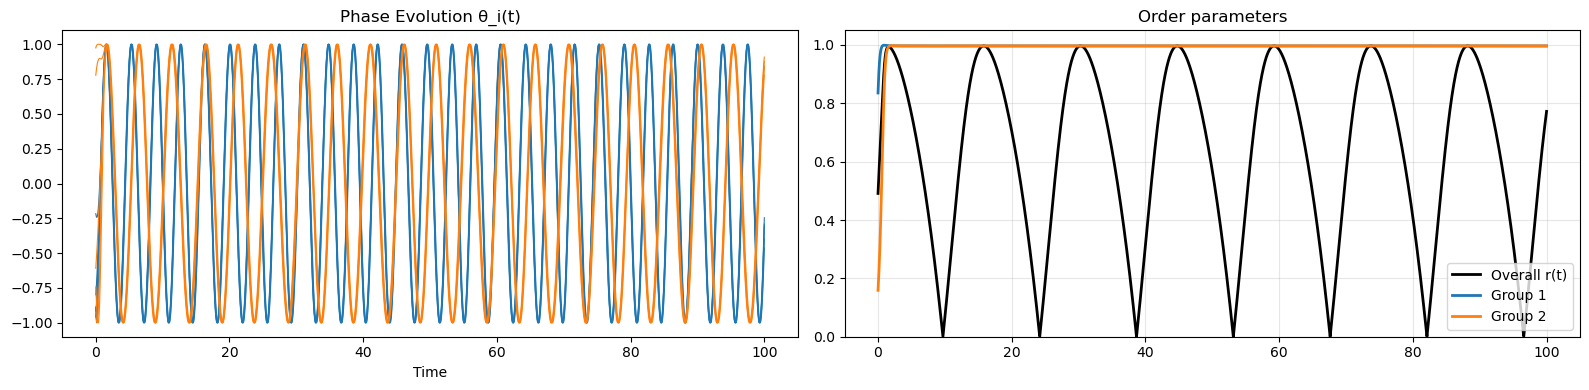

after burn-in: (9000, 20)
subsampled data shape: (600, 20)
dt_sample = 0.1500, tau = 9.0000


In [3]:
# 单时间序列采样
x_train, theta_hist, t_train, K_matrix = plot_clustered_kuramoto(
    N=N,
    n_clusters=n_clusters,
    K_intra=K_intra,
    K_inter=K_inter,
    noise=noise,
    T=T,
    random_seed1=0,
    random_seed2=0,
    dt=dt,
)

x_data_full = x_train[burn_in:, :]
x_data = x_data_full[::sample_stride, :].copy()
dt_sample = dt * sample_stride
tau = dt_sample * lag_steps

print(f"after burn-in: {x_data_full.shape}")
print(f"subsampled data shape: {x_data.shape}")
print(f"dt_sample = {dt_sample:.4f}, tau = {tau:.4f}")


# 选择library

In [4]:
# 候选的观测函数
ide = ps.IdentityLibrary()
fourier = ps.FourierLibrary(n_frequencies=1)
ode_lib = ps.PolynomialLibrary(degree=2, include_bias=False)
library_functions = [
    lambda x: 1,
    lambda x: x,
    lambda x: np.sin(x),
    lambda x: np.cos(x),
]
custom_library = ps.CustomLibrary(library_functions=library_functions)

# 最佳设置：先在原始 sin/cos 观测上做 Identity lift，再做轻量 PCA 预压缩
library = ide
library.fit(x_data)
x_data_lift = library.transform(x_data)
raw_names = library.get_feature_names()

pca_model = PCA(n_components=pca_dim)
x_data_fit = pca_model.fit_transform(x_data_lift)
fit_names = [f"pc{i + 1}" for i in range(pca_dim)]

print(f"raw feature shape: {x_data_lift.shape}")
print(f"PCA feature shape: {x_data_fit.shape}")
print("explained variance ratio:", np.round(pca_model.explained_variance_ratio_, 4))
print("cumulative explained variance:", np.round(np.cumsum(pca_model.explained_variance_ratio_), 4))


raw feature shape: (600, 20)
PCA feature shape: (600, 3)
explained variance ratio: [0.2755 0.2734 0.2281]
cumulative explained variance: [0.2755 0.5489 0.777 ]


lag_steps = 60, tau = 9.0000
配对样本数: 540
C00 shape: (3, 3), C01 shape: (3, 3), C11 shape: (3, 3)
C00 condition number: 1.1910e+00
C11 condition number: 1.3245e+00
min eig(C00): 2.2951e+00
min eig(C11): 2.1676e+00


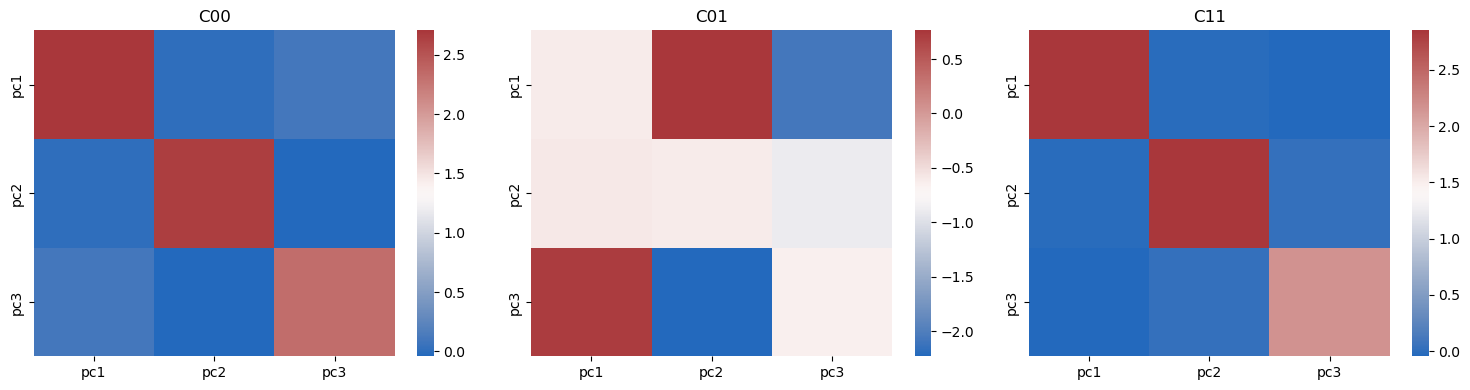

In [5]:
# 用 tau 配对样本估计 C00, C01, C11，这才是白化 Koopman 矩阵对应的统计量
transition_stats = compute_transition_covariances([x_data_fit], weights="uniform", lag_steps=lag_steps)
C00 = transition_stats["C00"]
C01 = transition_stats["C01"]
C11 = transition_stats["C11"]

print(f"lag_steps = {lag_steps}, tau = {tau:.4f}")
print(f"配对样本数: {transition_stats['X'].shape[0]}")
print(f"C00 shape: {C00.shape}, C01 shape: {C01.shape}, C11 shape: {C11.shape}")
print(f"C00 condition number: {np.linalg.cond(C00):.4e}")
print(f"C11 condition number: {np.linalg.cond(C11):.4e}")
print(f"min eig(C00): {np.min(np.linalg.eigvalsh(0.5 * (C00 + C00.T))):.4e}")
print(f"min eig(C11): {np.min(np.linalg.eigvalsh(0.5 * (C11 + C11.T))):.4e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mat, title in zip(axes, [C00, C01, C11], ["C00", "C01", "C11"]):
    sns.heatmap(mat, ax=ax, cmap="vlag", xticklabels=fit_names, yticklabels=fit_names)
    ax.set_title(title)
plt.tight_layout()
plt.show()


# 进行拟合

In [6]:
x_data_fit.shape


(600, 3)

In [7]:
# 连续时间拟合，然后与 tau-step 的经验 Koopman 做比较
discrete_time = False

sr3_optimizer = ps.SR3(reg_weight_lam=0.2, regularizer="l2")
lasso_optimizer = Lasso(alpha=0.005, max_iter=20000, fit_intercept=False)
stlsq_optimizer = ps.STLSQ(threshold=0.01, alpha=0.9, verbose=True)

optimizer = lasso_optimizer

# 这里 x_data_fit 已经是 PCA 预压缩后的观测，因此拟合阶段仍用 IdentityLibrary
model = ps.SINDy(feature_library=ide, optimizer=optimizer, discrete_time=discrete_time)
model.fit(x_data_fit, t=dt_sample, feature_names=fit_names)
model.print()


(pc1)' = -0.005 pc1 + 1.472 pc2 + 0.239 pc3
(pc2)' = -1.472 pc1 + -0.003 pc2 + -0.163 pc3
(pc3)' = -0.192 pc1 + 0.141 pc2 + 0.005 pc3


In [8]:
# 计算 score
model.score(x_data_fit, t=dt_sample)


0.6720723610071632

# 多步预测

In [9]:
test_idx = 0
init_data = x_data_fit[0, :]
step_pred = min(300, len(x_data_fit))

if discrete_time:
    X_data_predicted = model.simulate(init_data, step_pred)
else:
    t_pred = np.arange(step_pred) * dt_sample
    X_data_predicted = model.simulate(init_data, t_pred)

X_data_predicted.shape


(300, 3)

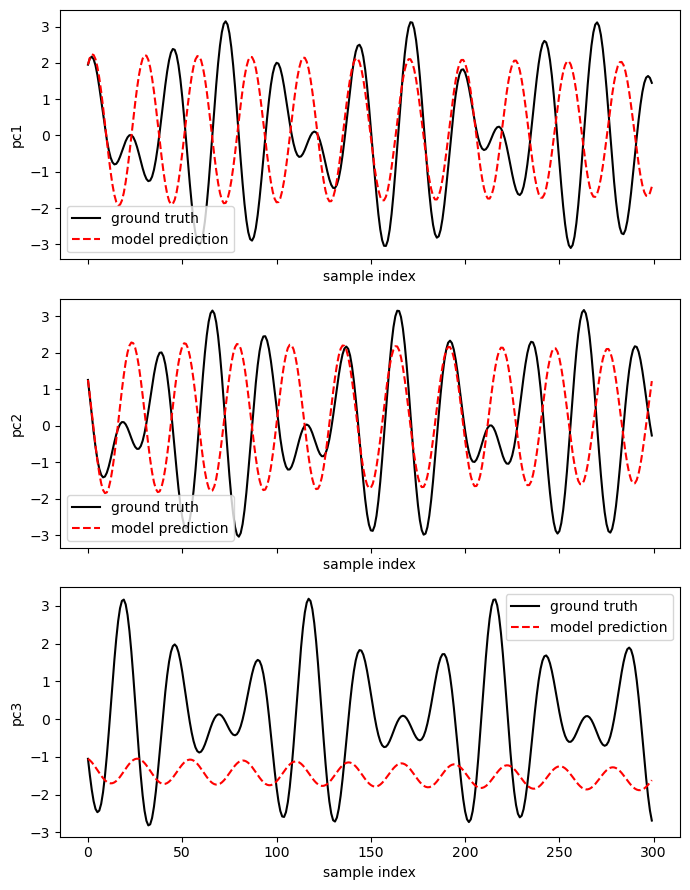

In [10]:
# 只看部分维度的多步预测
n_plot = min(3, x_data_fit.shape[1])
fig, axs = plt.subplots(n_plot, 1, sharex=True, figsize=(7, 3 * n_plot))
if n_plot == 1:
    axs = [axs]
for i in range(n_plot):
    axs[i].plot(x_data_fit[:step_pred, i], "k", label="ground truth")
    axs[i].plot(X_data_predicted[:step_pred, i], "r--", label="model prediction")
    axs[i].legend()
    axs[i].set(xlabel="sample index", ylabel=fit_names[i])
fig.tight_layout()
plt.show()


# svd分解

orientation check: err(A)=2.000e+00, err(A.T)=0.000e+00
tau = 9.0000 (lag_steps=60, dt_sample=0.1500)
||A_tau_data - A_tau_model||_F = 2.532e+00
max sv(A_tau_data)       = 1.108615
max sv(K_bar_model)      = 1.072812
max sv(K_bar empirical)  = 0.993359


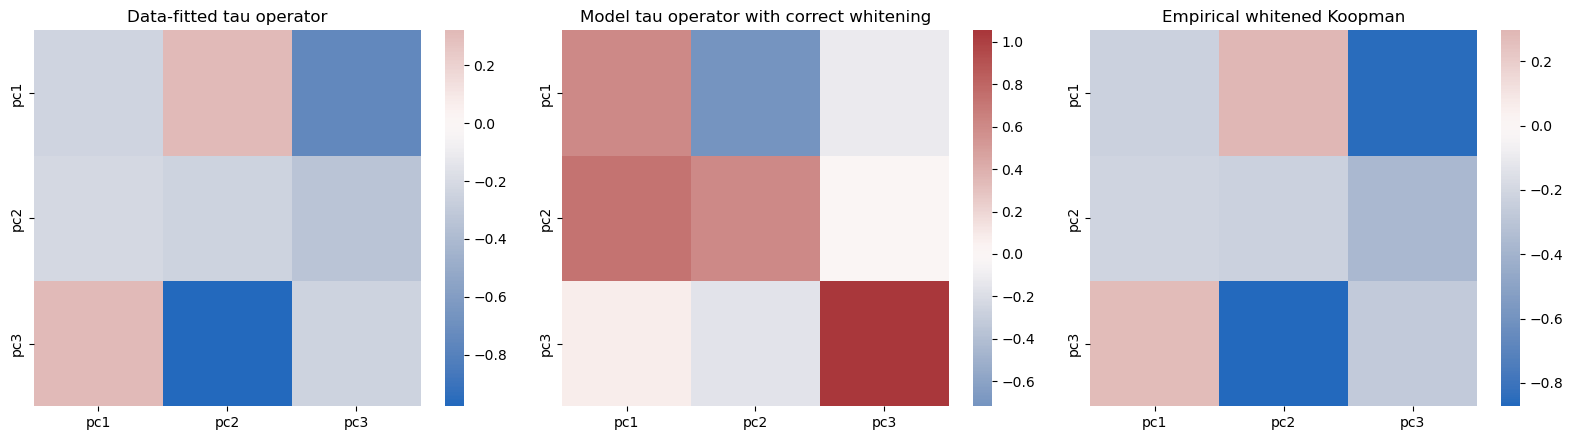

In [11]:
A_raw = model.coefficients()

# 系数方向一致性检查：选预测误差更小的方向
xdot_model = model.predict(x_data_fit)
err_no_t = np.linalg.norm(xdot_model - x_data_fit @ A_raw.T) / np.linalg.norm(xdot_model)
err_t = np.linalg.norm(xdot_model - x_data_fit @ A_raw) / np.linalg.norm(xdot_model)
A_ct = A_raw if err_t <= err_no_t else A_raw.T
print(f"orientation check: err(A)={err_t:.3e}, err(A.T)={err_no_t:.3e}")

# 连续系统转 tau-step 离散算子
if discrete_time:
    A_step_model = A_ct
    A_tau_model = np.linalg.matrix_power(A_step_model, lag_steps)
else:
    A_tau_model = scipy.linalg.expm(A_ct * tau)

koop_fit = fit_data_koopman_operator([x_data_fit], weights="uniform", eps=1e-10, ridge=1e-10, lag_steps=lag_steps)
A_tau_data = koop_fit["A"]
K_bar = koop_fit["K_bar"]
C00 = koop_fit["C00"]
C01 = koop_fit["C01"]
C11 = koop_fit["C11"]
C00_inv_sqrt = koop_fit["C00_inv_sqrt"]
C11_inv_sqrt = koop_fit["C11_inv_sqrt"]

model_whitening = whiten_operator_matrix(A_tau_model, C00, C11, eps=1e-10)
K_bar_model = model_whitening["A_bar"]

print(f"tau = {tau:.4f} (lag_steps={lag_steps}, dt_sample={dt_sample:.4f})")
print(f"||A_tau_data - A_tau_model||_F = {np.linalg.norm(A_tau_data - A_tau_model):.3e}")
print(f"max sv(A_tau_data)       = {np.linalg.svd(A_tau_data, compute_uv=False)[0]:.6f}")
print(f"max sv(K_bar_model)      = {np.linalg.svd(K_bar_model, compute_uv=False)[0]:.6f}")
print(f"max sv(K_bar empirical)  = {np.linalg.svd(K_bar, compute_uv=False)[0]:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
panels = [
    (A_tau_data, "Data-fitted tau operator"),
    (K_bar_model, "Model tau operator with correct whitening"),
    (K_bar, "Empirical whitened Koopman"),
]
for ax, (mat, title) in zip(axes, panels):
    sns.heatmap(mat, ax=ax, xticklabels=fit_names, yticklabels=fit_names, cmap="vlag", center=0)
    ax.set_title(title)
plt.tight_layout()
plt.show()


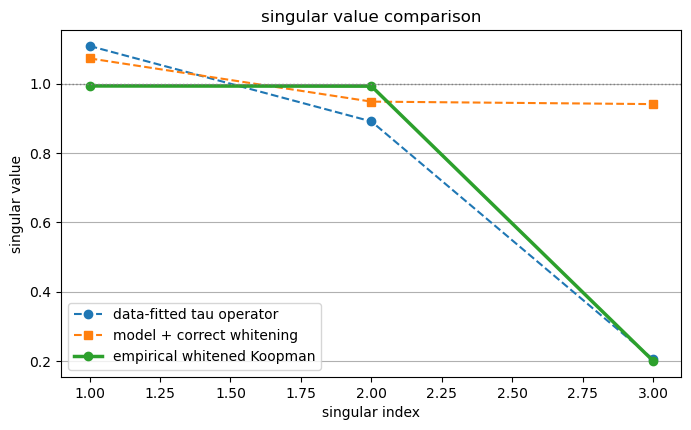

In [12]:
U, S, Vt = np.linalg.svd(K_bar)
S_raw = np.linalg.svd(A_tau_data, compute_uv=False)
S_model = np.linalg.svd(K_bar_model, compute_uv=False)

plt.figure(figsize=(8, 4.5))
idx = np.arange(1, len(S) + 1)
plt.plot(idx, S_raw, "o--", label="data-fitted tau operator")
plt.plot(idx, S_model, "s--", label="model + correct whitening")
plt.plot(idx, S, "o-", linewidth=2.5, label="empirical whitened Koopman")
plt.axhline(1.0, color="gray", linestyle=":", linewidth=1)
plt.grid(True, axis="y")
plt.xlabel("singular index")
plt.ylabel("singular value")
plt.title("singular value comparison")
plt.legend()
plt.show()


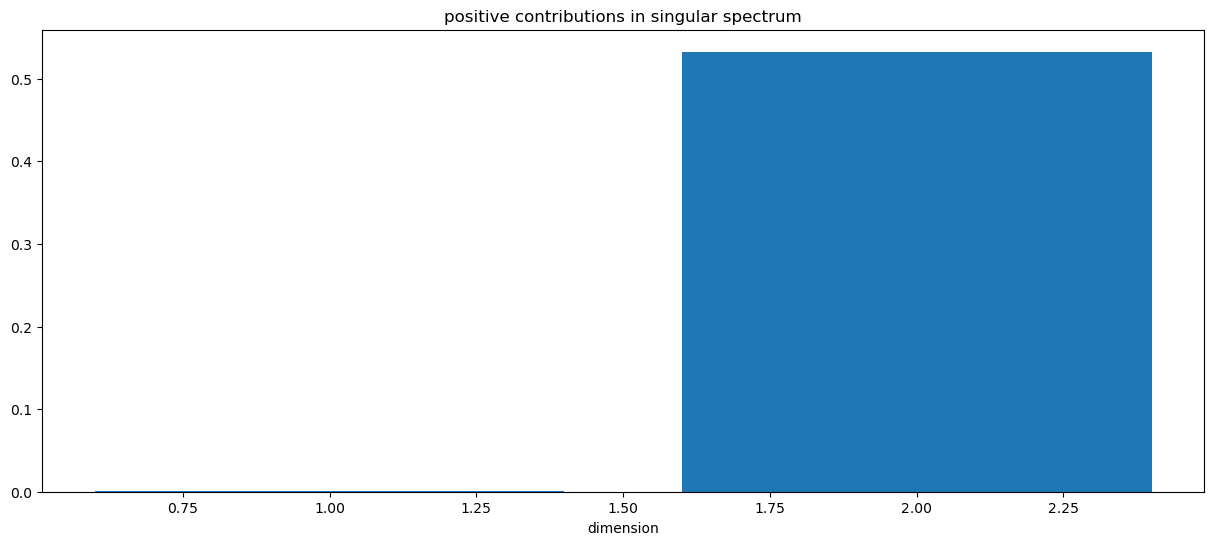

In [13]:
# 多尺度因果力分布
diff = get_positive_contributions(S)
plt.figure(figsize=(15, 6))
plt.bar(range(1,len(diff)+1), diff) 
plt.xlabel('dimension')
plt.title('positive contributions in singular spectrum')
plt.show()

In [14]:
# 选取截断
S_macro = S[:rank]
delt_gamma = sum(S_macro) / rank - sum(S) / len(S)
print(f"rank = {rank}")
print(f"top singular values = {np.round(S[:5], 4)}")
print(f"delta_gamma = {delt_gamma:.6f}")


rank = 2
top singular values = [0.9934 0.9928 0.2008]
delta_gamma = 0.264075


In [15]:
# 计算EC
print(compute_entropy(diff))

0.006668602715507754


# 输出粗粒化表达式

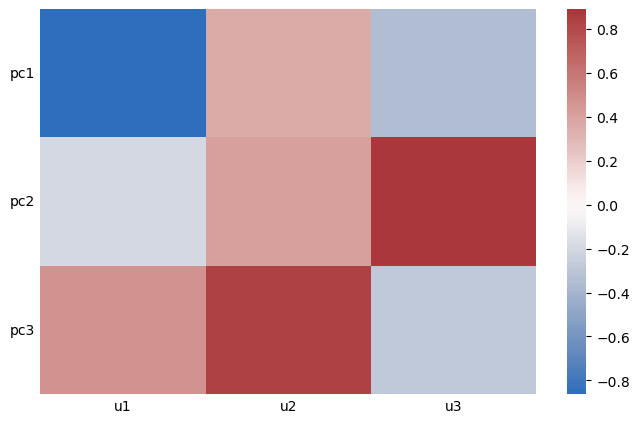

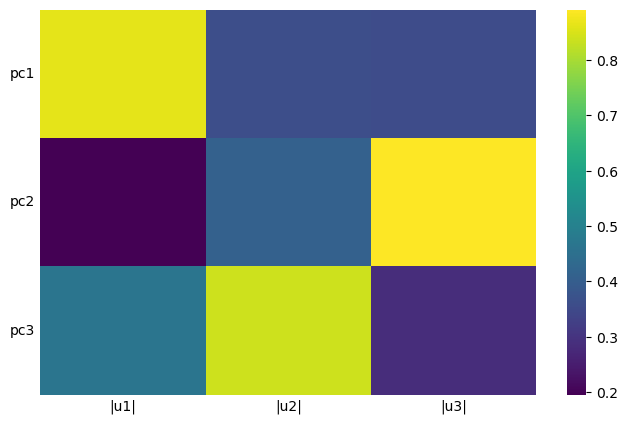

In [16]:
# 绘制奇异向量（PCA 坐标下）
U_abs = np.abs(U)

plt.figure(figsize=(8, 5))
plt.tick_params(axis="both", which="both", length=0)
_ = sns.heatmap(U, yticklabels=fit_names, xticklabels=[f"u{i+1}" for i in range(U.shape[1])], cmap="vlag", center=0)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

plt.figure(figsize=(8, 5))
plt.tick_params(axis="both", which="both", length=0)
_ = sns.heatmap(U_abs, yticklabels=fit_names, xticklabels=[f"|u{i+1}|" for i in range(U.shape[1])], cmap="viridis")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()


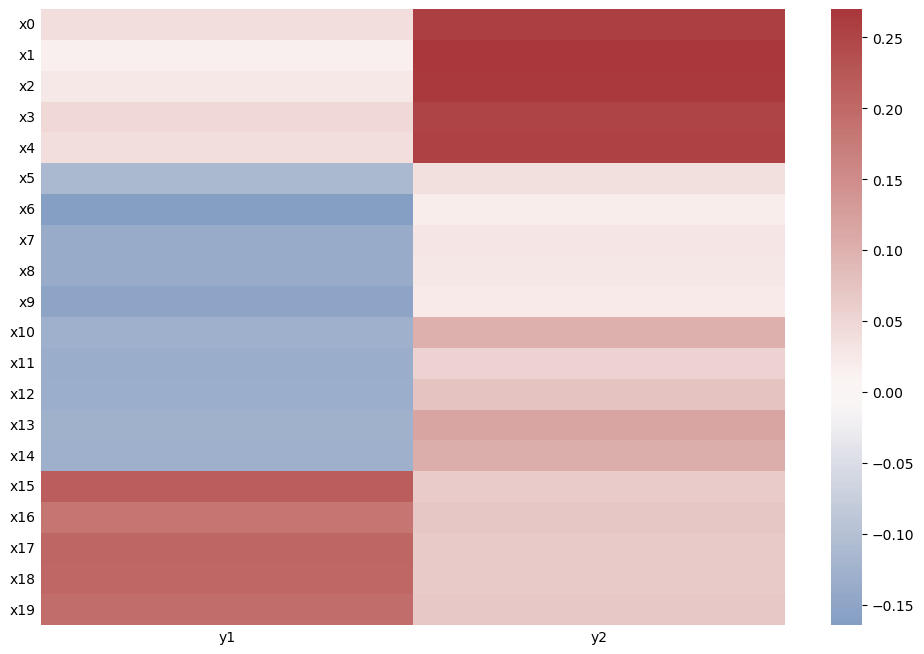

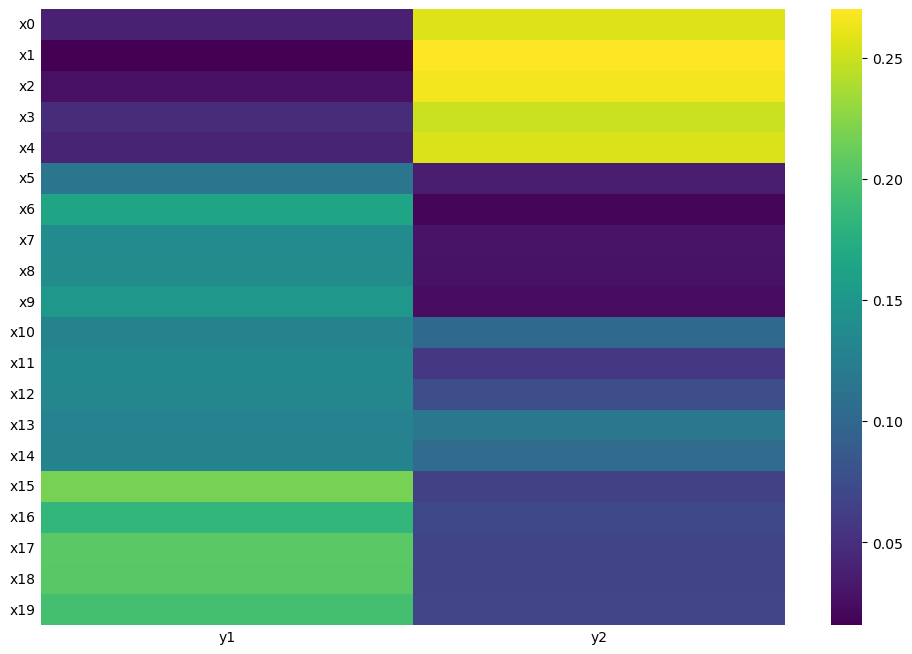

,cluster_1,cluster_2
y1,0.822316,1.710315
y2,1.751365,0.477679


In [17]:
# 粗粒化函数系数：先在 PCA 空间取左奇异函数，再映回原始 sin/cos 观测
macro_name = [f"y{i+1}" for i in range(rank)]
coarse_grain_coff_pca = C00_inv_sqrt @ U[:, :rank]
coarse_grain_coff = pca_model.components_.T @ coarse_grain_coff_pca
macro_bias = -pca_model.mean_ @ coarse_grain_coff

plt.figure(figsize=(12, 8))
plt.tick_params(axis="both", which="both", length=0)
_ = sns.heatmap(coarse_grain_coff, yticklabels=raw_names, xticklabels=macro_name, cmap="vlag", center=0)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

plt.figure(figsize=(12, 8))
plt.tick_params(axis="both", which="both", length=0)
_ = sns.heatmap(np.abs(coarse_grain_coff), yticklabels=raw_names, xticklabels=macro_name, cmap="viridis")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

cluster_size = N // n_clusters
cluster_loading = np.zeros((rank, n_clusters))
for feat_idx, name in enumerate(raw_names):
    base_idx = int(name[1:])
    cluster_idx = min((base_idx % N) // cluster_size, n_clusters - 1)
    for macro_idx in range(rank):
        cluster_loading[macro_idx, cluster_idx] += abs(coarse_grain_coff[feat_idx, macro_idx])

cluster_loading_df = pd.DataFrame(
    cluster_loading,
    index=macro_name,
    columns=[f"cluster_{i+1}" for i in range(n_clusters)],
)
cluster_loading_df


In [18]:
# 输出粗粒化函数表达式（原始 sin/cos 观测坐标）
print_equations(coarse_grain_coff, raw_names, macro_name)
print("macro bias terms:")
for name, bias in zip(macro_name, macro_bias):
    print(f"{name} += {bias:.4f}")


y1 = 0.0390 * x0 + 0.0158 * x1 + 0.0258 * x2 + 0.0469 * x3 + 0.0407 * x4 - 0.1150 * x5 - 0.1645 * x6 - 0.1372 * x7 - 0.1385 * x8 - 0.1515 * x9 - 0.1298 * x10 - 0.1348 * x11 - 0.1332 * x12 - 0.1271 * x13 - 0.1292 * x14 + 0.2177 * x15 + 0.1834 * x16 + 0.2045 * x17 + 0.2037 * x18 + 0.1943 * x19
------------------------------
y2 = 0.2566 * x0 + 0.2700 * x1 + 0.2652 * x2 + 0.2500 * x3 + 0.2552 * x4 + 0.0360 * x5 + 0.0195 * x6 + 0.0291 * x7 + 0.0287 * x8 + 0.0242 * x9 + 0.1014 * x10 + 0.0559 * x11 + 0.0755 * x12 + 0.1167 * x13 + 0.1048 * x14 + 0.0646 * x15 + 0.0707 * x16 + 0.0677 * x17 + 0.0679 * x18 + 0.0694 * x19
------------------------------
macro bias terms:
y1 += 0.0165
y2 += 0.0166


# 描述宏观演化

best frequency assignment: (1, 0)
best average frequency mismatch: 0.000000
cluster frequencies: [0.26666666666666666, 0.2]
macro frequencies after alignment: [0.26666666666666666, 0.2]


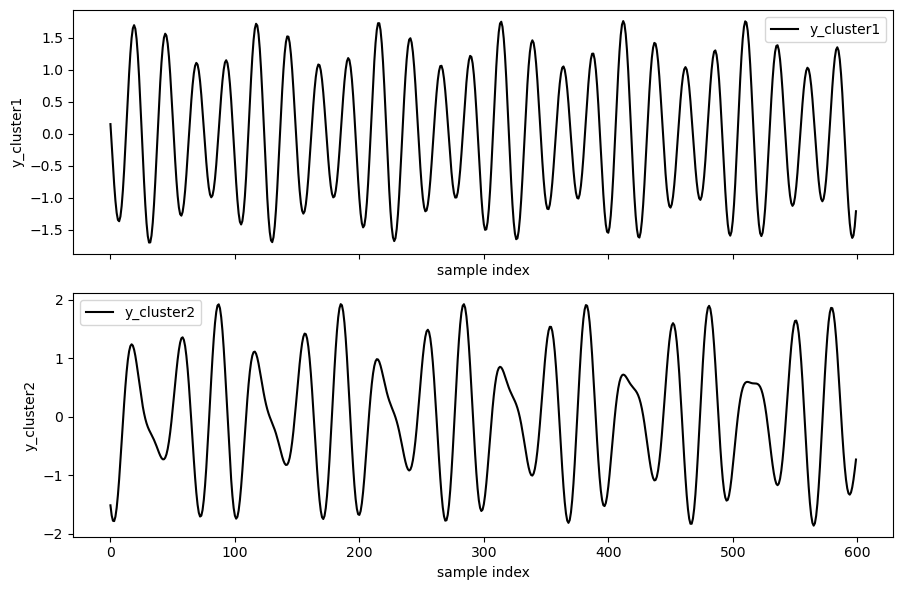

In [19]:
macro_data_raw = x_data_fit @ coarse_grain_coff_pca
cluster_mean_signals = []
for cluster_idx in range(n_clusters):
    start = cluster_idx * (N // n_clusters)
    end = N if cluster_idx == n_clusters - 1 else (cluster_idx + 1) * (N // n_clusters)
    cluster_mean_signals.append(np.mean(x_data[:, start:end], axis=1))
cluster_mean_signals = np.column_stack(cluster_mean_signals)

macro_freqs_raw = [dominant_frequency(macro_data_raw[:, i], dt_sample) for i in range(rank)]
cluster_freqs = [dominant_frequency(cluster_mean_signals[:, j], dt_sample) for j in range(n_clusters)]
freq_diff_matrix = np.array([
    [abs(macro_freqs_raw[i] - cluster_freqs[j]) for j in range(n_clusters)]
    for i in range(rank)
])
best_freq_mismatch, best_freq_perm = best_assignment_score(freq_diff_matrix, maximize=False)
macro_order = np.argsort(best_freq_perm)

macro_data = macro_data_raw[:, macro_order]
macro_name_aligned = [f"y_cluster{i+1}" for i in range(rank)]
macro_freqs = [dominant_frequency(macro_data[:, i], dt_sample) for i in range(rank)]

print(f"best frequency assignment: {best_freq_perm}")
print(f"best average frequency mismatch: {best_freq_mismatch / rank:.6f}")
print("cluster frequencies:", cluster_freqs)
print("macro frequencies after alignment:", macro_freqs)

fig, axs = plt.subplots(rank, 1, sharex=True, figsize=(9, 3 * rank))
if rank == 1:
    axs = [axs]
for i in range(rank):
    axs[i].plot(macro_data[:, i], "k", label=macro_name_aligned[i])
    axs[i].legend()
    axs[i].set(xlabel="sample index", ylabel=macro_name_aligned[i])
fig.tight_layout()
plt.show()


In [20]:
# 给出宏观 tau-step 动力学方程
A_macro = np.linalg.lstsq(macro_data[:-lag_steps], macro_data[lag_steps:], rcond=None)[0]
macro_name_k = [f"{name}[k]" for name in macro_name_aligned]
macro_name_next = [f"{name}[k+tau]" for name in macro_name_aligned]
print_equations(A_macro, macro_name_k, macro_name_next)


y_cluster1[k+tau] = -0.8410 * y_cluster1[k] + 0.4080 * y_cluster2[k]
------------------------------
y_cluster2[k+tau] = -0.2414 * y_cluster1[k] + 0.1072 * y_cluster2[k]
------------------------------


# 频谱分析

           cluster_freq  macro_freq
cluster_1      0.266667    0.266667
cluster_2      0.200000    0.200000


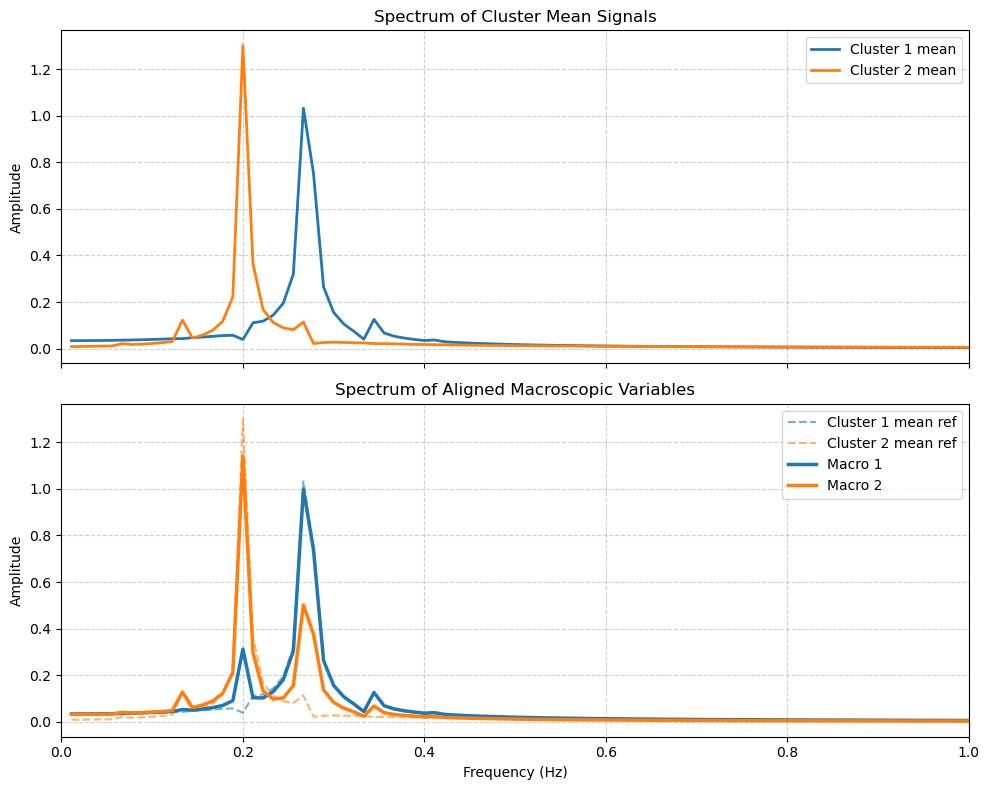

In [21]:
from scipy.fft import fft

n_fft = macro_data.shape[0]
xf = np.fft.fftfreq(n_fft, dt_sample)
cluster_labels = [f"Cluster {i+1} mean" for i in range(n_clusters)]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

macro_signals = [standardize_signal(macro_data[:, i]) for i in range(rank)]
cluster_signals = [standardize_signal(cluster_mean_signals[:, i]) for i in range(n_clusters)]
macro_labels = [f"Macro {i+1}" for i in range(rank)]

freq_summary = pd.DataFrame(
    {
        "cluster_freq": cluster_freqs,
        "macro_freq": macro_freqs,
    },
    index=[f"cluster_{i+1}" for i in range(n_clusters)],
)
print(freq_summary)


def compute_fft(signal, xf, n_fft):
    yf = fft(signal)
    positive = xf > 0
    return xf[positive], np.abs(yf[positive]) / n_fft * 2


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for i, sig in enumerate(cluster_signals):
    freqs, amps = compute_fft(sig, xf, n_fft)
    ax1.plot(freqs, amps, label=cluster_labels[i], color=colors[i], linewidth=2)

ax1.set_title("Spectrum of Cluster Mean Signals")
ax1.set_ylabel("Amplitude")
ax1.legend(loc="upper right")
ax1.grid(True, linestyle="--", alpha=0.6)

for i, sig in enumerate(cluster_signals):
    freqs, amps = compute_fft(sig, xf, n_fft)
    ax2.plot(freqs, amps, "--", label=f"{cluster_labels[i]} ref", color=colors[i], alpha=0.6)
for i, sig in enumerate(macro_signals):
    freqs, amps = compute_fft(sig, xf, n_fft)
    ax2.plot(freqs, amps, label=macro_labels[i], color=colors[i], linewidth=2.5)

ax2.set_title("Spectrum of Aligned Macroscopic Variables")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Amplitude")
ax2.legend(loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()


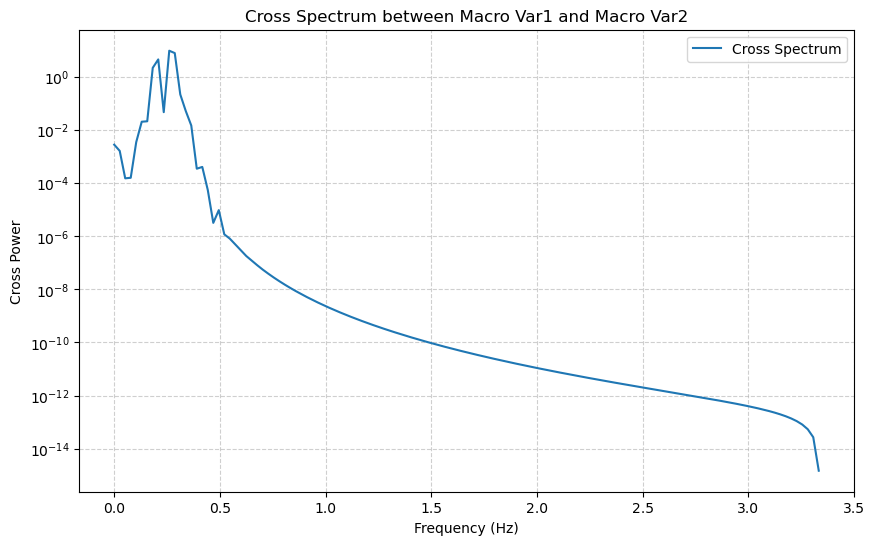

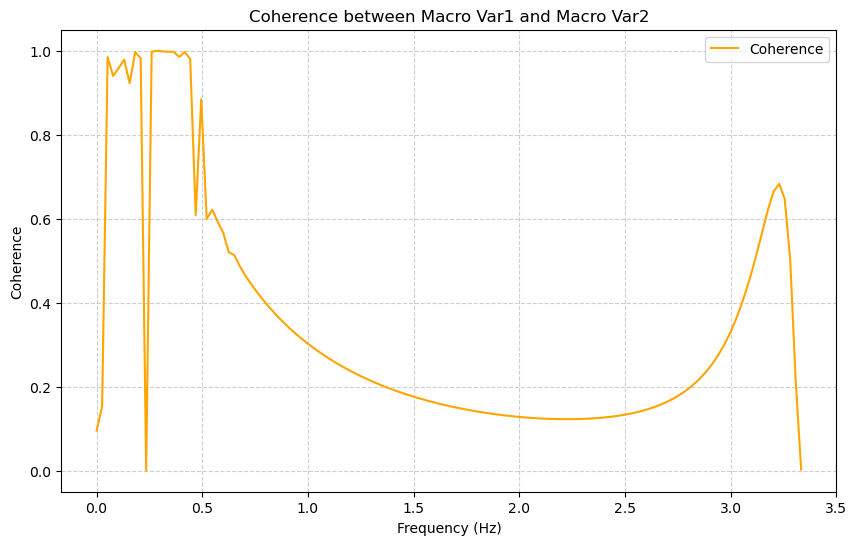

In [22]:
from scipy.signal import coherence, csd

# 计算交叉频谱和相干性
def compute_cross_spectrum_and_coherence(signal1, signal2, fs):
    f, Pxy = csd(signal1, signal2, fs=fs, nperseg=min(256, len(signal1)))
    f_coh, Cxy = coherence(signal1, signal2, fs=fs, nperseg=min(256, len(signal1)))
    return f, Pxy, f_coh, Cxy

fs = 1 / dt_sample
macro_var1 = macro_signals[0]
macro_var2 = macro_signals[1]

f, Pxy, f_coh, Cxy = compute_cross_spectrum_and_coherence(macro_var1, macro_var2, fs)

plt.figure(figsize=(10, 6))
plt.semilogy(f, np.abs(Pxy), label="Cross Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Cross Power")
plt.title("Cross Spectrum between Macro Var1 and Macro Var2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(f_coh, Cxy, label="Coherence", color="orange")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence")
plt.title("Coherence between Macro Var1 and Macro Var2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
